# Organ-scale light interception in a growth chamber with SEC2 (openalea.spice) — reproduction notebook

Reproduction of the virtual-experiment step of:
**Demotes-Mainard S., Autret H., Pradal C., Le Gall J., Guérin V., Leduc N., Combes D., Renaud C., Chelle M., Bertheloot J.**
*Simulating light quantity and quality over plant organs using a ray-tracing method to investigate plant responses in growth chambers.* **Biosystems Engineering** (2025).
Landing page: https://europepmc.org/article/AGR/IND609292966 — author software: https://github.com/openalea/rose (linked from the Agritrop record 614367), light engine: https://github.com/openalea/spice.

**Executed scope (partial demonstration).** Following the authors' own example notebook
[`examples/light.ipynb`](https://github.com/openalea/rose/blob/master/examples/light.ipynb)
(rose repository pinned at commit `aa3390e5266ffad852319284d2b6b06708aaf722`), this notebook
reconstructs the digitised rose-bush mock-up of experiment manipulation **High_Light_Crop_1, stage FBV**
inside the growth-chamber scene, registers every plant organ as a photon face sensor, adds the four
chamber point lights used by the authors' example, and runs the SEC2 photon-mapping engine
(**openalea.spice 1.1.1**, the release matching the pinned repository tag `v1.1.1`) to obtain
relative photon interception per organ (1,000,000 photons, single uncalibrated default waveband).

**Not reproduced:** lamp-spectrum calibration with measured spectra, the RMSE validation against
chamber measurements, the two other virtual experiments, and the bud-outgrowth case study
(measured spectra are not available in the repositories).

**実行内容（部分的な再現）**: 著者らの例 `examples/light.ipynb` に従い、実験条件
High_Light_Crop_1（FBV ステージ）のバラ個体群モックアップを chamber 内で再構築し、
各器官を face sensor として登録、例と同じ 4 つの点光源を置き、SEC2 光子マッピング
エンジン (openalea.spice 1.1.1) で器官ごとの相対光子 intercepted 数を計算します
（100 万光子、較正なしの既定波帯）。ランプスペクトル較正・RMSE 検証・他の仮想実験・
腋芽ケーススタディは対象外です。

**AI-assisted adaptation notice / AI による適合修正について**
The authors did not provide this Colab notebook. The scientific operations (mock-up reconstruction,
scene conversion, photon-mapping configuration) are copied or directly called from the pinned author
code; the Colab/conda environment plumbing, the static painter's-algorithm visualisations, and one
API adaptation (spice 1.1.1 `pgl_to_spice(scene, sim, ...)` signature and `KEEP_ALL=True`, required
for face-sensor photon recording in this release — the 2025-06 rose example predates a 2025-04-14
spice API change, commit 466f6da8) are AI-generated glue. The executed example and listed checks
were validated, but untested behaviour is not guaranteed.
著者はこの Colab 実装を提供していません。科学的手順は pinned された著者コードからそのまま
呼び出し、Colab/conda 環境構築・静的可視化・API 適合は AI が追加したものです。

## Runtime selection / ランタイム選択

**Use a CPU runtime** (Runtime - Change runtime type - CPU). The SEC2 photon-mapping engine is a
CPU code (Embree + TBB/OpenMP); no GPU is used anywhere in this reproduction, so a GPU runtime
is unnecessary. Timings below are measured on 2026-10-09 on a standard Colab CPU runtime
(2 vCPU, ~12.7 GB RAM) and will be re-displayed from the actual run.

**CPU ランタイムを選択してください。** SEC2 は CPU 実装（Embree + TBB）で GPU は不要です。

In [ ]:
import os, platform, subprocess
print("Python:", platform.python_version())
print("Platform:", platform.platform())
print("CPUs:", os.cpu_count())
print(subprocess.run(["free", "-h"], capture_output=True, text=True).stdout)
if os.cpu_count() and os.cpu_count() < 2:
    print("WARNING: fewer than 2 CPUs detected; the simulation will be slower than the measured reference.")

Python: 3.13.16
Platform: Linux-6.6.122+-x86_64-with-glibc2.39
CPUs: 2
               total        used        free      shared  buff/cache   available
Mem:            12Gi       927Mi       8.8Gi       2.1Mi       3.2Gi        11Gi
Swap:             0B          0B          0B



## 1. Bootstrap micromamba

The OpenAlea scientific stack used by the paper is distributed through conda channels
(`openalea.spice` exists only on the `openalea3` conda channel, not on PyPI), so this notebook
installs the static **micromamba** binary under `/content` and creates a pinned environment.
Expected result: `bin/micromamba` extracted (a few seconds).

論文の OpenAlea スタックは conda チャネル配布のため、`/content` に micromamba を取得します。

In [ ]:
import subprocess
r = subprocess.run(
    "curl -Ls --retry 3 https://micro.mamba.pm/api/micromamba/linux-64/latest | tar -xvj -C /content bin/micromamba",
    shell=True, executable="/bin/bash",
)
print("curl+tar rc:", r.returncode)
assert r.returncode == 0, "micromamba download failed"

curl+tar rc: 0


## 2. Create the pinned environment

Create a python 3.11 environment with the authors' pinned release **openalea.spice=1.1.1**
(openalea3 channel, linux-64 builds published 2026-01-26; conda dependencies include embree,
tbb, llvm-openmp) plus **openalea.plantgl** for the PlantGL scene machinery and **openalea.core**
(noarch; the authors' `rose_geometry.py` imports `openalea.core.external`).
Expected: solver + download of ~1.5-2 GB, a few minutes, exit code 0.

py3.11 環境に openalea.spice=1.1.1、openalea.plantgl、openalea.core をインストールします（数分）。

In [ ]:
import os, subprocess, time
t0 = time.time()
env = dict(os.environ, MAMBA_ROOT_PREFIX="/content/mamba")
r = subprocess.run(
    ["/content/bin/micromamba", "create", "-y", "-p", "/content/env",
     "-c", "conda-forge", "-c", "openalea3",
     "python=3.11", "openalea.spice=1.1.1", "openalea.plantgl", "openalea.core"],
    env=env,
)
print("micromamba create rc:", r.returncode, "elapsed_s:", round(time.time() - t0, 1))
assert r.returncode == 0, "conda env creation failed"

micromamba create rc: 0 elapsed_s: 100.0


## 3. Verify the photon-mapping engine imports

Check that the compiled spice extension (nanobind over the Embree/TBB C++ core) imports in the
environment and that `Simulator` is available. Expected: `spice ok` and the site-packages path.

コンパイル済みエンジンの import を確認します。

In [ ]:
import subprocess
check = (
    "import openalea.spice; "
    "from openalea.spice.libspice import Vec3; "
    "from openalea.spice.simulator import Simulator; "
    "print('spice ok', openalea.spice.__file__)"
)
r = subprocess.run(["/content/env/bin/python", "-c", check], capture_output=True, text=True)
print(r.stdout or r.stderr[-2000:])
assert r.returncode == 0, "openalea.spice import failed"

spice ok /content/env/lib/python3.11/site-packages/openalea/spice/__init__.py



## 4. Install the authors' openalea.mtg (pinned GitHub commit)

The `openalea3` conda channel ships `openalea.mtg` only up to python 3.9, so install it from the
authors' repository at pinned commit `34e15035db` (pure Python; dependency: pandas, already in the
env). Expected: pip exit code 0.

openalea.mtg は py3.9 までしか conda にないため、著者リポジトリの pinned commit から
pip でインストールします。

In [ ]:
import subprocess
r = subprocess.run(["/content/env/bin/pip", "install", "-q",
                    "git+https://github.com/openalea/mtg@34e15035db"])
print("pip mtg rc:", r.returncode)
assert r.returncode == 0, "openalea.mtg install failed"

pip mtg rc: 0


## 5. Pinned partial clone of openalea/rose with the experiment data

Clone the author repository **inside Colab only**, pinned to the exact commit
`aa3390e5266ffad852319284d2b6b06708aaf722` (master head 2025-06-23, the commit inspected for this reproduction), with a
blobless partial clone and a sparse checkout of `src/openalea/rose` — the package code plus the
embedded experiment data (MTG digitisations, `data/GEOM/chamber.bgeom` chamber geometry, CAN/EXPE2/SENSORS
inputs). The checked-out commit is asserted to match the pin. All repository and dataset bytes stay
under `/content` on the Colab VM.

Expected: `PIN_OK` confirming the checked-out commit.

著者リポジトリを Colab 内で partial clone し、pinned commit `aa3390e5...` と一致することを
確認します。データはすべて Colab VM 上の `/content` に置かれます。

In [ ]:
import subprocess
cmds = [
    "git clone --filter=blob:none --no-checkout https://github.com/openalea/rose /content/rose",
    "cd /content/rose && git fetch --depth 1 origin aa3390e5266ffad852319284d2b6b06708aaf722",
    "cd /content/rose && git sparse-checkout set src/openalea/rose",
    "cd /content/rose && git checkout FETCH_HEAD",
    'cd /content/rose && test "$(git rev-parse HEAD)" = "aa3390e5266ffad852319284d2b6b06708aaf722" && echo PIN_OK',
]
for c in cmds:
    r = subprocess.run(c, shell=True, executable="/bin/bash", capture_output=True, text=True)
    tail = (r.stdout + r.stderr).strip().splitlines()[-1:]
    print(r.returncode, tail[0] if tail else "")
r = subprocess.run("cd /content/rose && git rev-parse HEAD", shell=True, capture_output=True, text=True)
assert r.stdout.strip() == "aa3390e5266ffad852319284d2b6b06708aaf722", "checked-out commit does not match the pin: " + r.stdout

0 Cloning into '/content/rose'...


0  * branch            aa3390e5266ffad852319284d2b6b06708aaf722 -> FETCH_HEAD
0 


0 HEAD is now at aa3390e Merge pull request #17 from openalea/notebook
0 PIN_OK


## 6. Editable install of openalea.rose

Install the authors' rose package **editable and without deps** so that `openalea.rose.data` resolves
the experiment data files from the checkout on disk (a regular wheel install would omit
`data/GEOM/*.bgeom` and the CAN JSONs from `package-data`). Then verify the manipulation listing.
Expected: `pip rose rc: 0` and the six manipulation folders (`High_Light_Crop_1..3`, `Low_Light_Crop_1..3`).

rose パッケージを editable（--no-deps）でインストールし、manips 一覧を確認します。

In [ ]:
import subprocess
r = subprocess.run(["/content/env/bin/pip", "install", "-q", "-e", "/content/rose", "--no-deps"])
print("pip rose rc:", r.returncode)
assert r.returncode == 0, "openalea.rose install failed"
check = (
    "from openalea.rose.data import manips, experiments; "
    "print(sorted(manips())); "
    "print([str(e) for e in experiments('High_Light_Crop_1')])"
)
r = subprocess.run(["/content/env/bin/python", "-c", check], capture_output=True, text=True)
print(r.stdout or r.stderr[-2000:])
assert r.returncode == 0 and "High_Light_Crop_1" in r.stdout, "manip listing failed"

pip rose rc: 0


['High_Light_Crop_1', 'High_Light_Crop_2', 'High_Light_Crop_3', 'Low_Light_Crop_1', 'Low_Light_Crop_2', 'Low_Light_Crop_3']
['/content/rose/src/openalea/rose/data/MTG/High_Light_Crop_1/PCV', '/content/rose/src/openalea/rose/data/MTG/High_Light_Crop_1/FBV', '/content/rose/src/openalea/rose/data/MTG/High_Light_Crop_1/OF']



## 7. Verify the pinned input data actually present

Validate the experiment inputs that this demonstration consumes, straight from the downloaded bytes:
the 34 digitised plant MTGs of `High_Light_Crop_1/FBV`, the `grid.txt` plant-layout grid, `origin.txt`,
and the chamber geometry `chamber.bgeom` (its SHA-256 prefix and size are printed for provenance).
Expected: 34 `.mtg` files, non-empty grid/origin, a ~21 KB `.bgeom`.

このデモが使う実験データ（MTG 35 個体、grid/origin、chamber.bgeom）の実バイトを検証します。

In [ ]:
import subprocess
check = '''
from pathlib import Path
import hashlib
base = Path("/content/rose/src/openalea/rose/data")
mtgs = sorted((base / "MTG/High_Light_Crop_1/FBV").glob("*.mtg"))
print("FBV plant MTGs:", len(mtgs))
b = (base / "GEOM/chamber.bgeom").read_bytes()
print("chamber.bgeom bytes:", len(b), "sha256:", hashlib.sha256(b).hexdigest()[:16], "...")
print("grid.txt:", (base / "MTG/High_Light_Crop_1/FBV/grid.txt").read_text().strip()[:120])
print("origin.txt:", (base / "MTG/High_Light_Crop_1/FBV/origin.txt").read_text().strip())
assert len(mtgs) == 34 and len(b) > 10000
'''
r = subprocess.run(["/content/env/bin/python", "-c", check], capture_output=True, text=True)
print(r.stdout or r.stderr[-2000:])
assert r.returncode == 0, "input data verification failed"

FBV plant MTGs: 34
chamber.bgeom bytes: 21969 sha256: 036347590ad2f9ab ...
grid.txt: 13	6	150	150
32	0	0
143	1	0
98	2	0
35	3	0
34	4	0
213	5	0
193	6	0
165	7	0
80	8	0
41	9	0
99	10	0
51	11	0
15	12	0
125	0	1
5
origin.txt: x,y,z
100,530,900



## 8. Helper for static rendering (AI-generated)

Write `00_scene_utils.py`: a tesselator-to-triangles extractor and an orthographic
painter's-algorithm renderer. This replaces the example's interactive k3d/oawidgets viewers with
durable static PNGs (AI-generated visualisation helper, not author code). Expected: `utils ok`.

静的レンダリング用ヘルパー（AI 生成）を `/content` に書き込み、動作確認します。

In [ ]:
import pathlib, subprocess
utils = '''
import numpy as np

def scene_triangles(scene, skip_text=True):
    # Tesselate a PlantGL scene into per-triangle arrays: positions, colors, alphas.
    from openalea.plantgl.all import Tesselator
    tr = Tesselator()
    tris, cols, alphas = [], [], []
    for sh in scene:
        sh.apply(tr)
        g = tr.result
        if g is None or len(g.pointList) == 0:
            continue
        pts = np.array([[p.x, p.y, p.z] for p in g.pointList], dtype=float)
        alpha = 1.0
        if sh.appearance is not None:
            c = sh.appearance.ambient
            col = (c.red / 255.0, c.green / 255.0, c.blue / 255.0)
            if sh.appearance.transparency and sh.appearance.transparency > 0:
                alpha = max(0.08, 1.0 - sh.appearance.transparency)
        else:
            col = (0.6, 0.6, 0.6)
        for t in g.indexList:
            tris.append(pts[list(t)])
            cols.append(col)
            alphas.append(alpha)
    return np.array(tris), np.array(cols), np.array(alphas)


def painter_render(tris, colors, out_path, view=(1.0, -1.0, 0.9), title="",
                   vmin=None, vmax=None, target_aspect=16 / 9, max_tris=250000,
                   cmap_name="jet"):
    # Static orthographic painter's-algorithm render (AI helper, not author code).
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    from matplotlib.collections import PolyCollection
    from matplotlib import cm, colors as mcolors

    tris = np.asarray(tris)
    colors = np.asarray(colors, dtype=float)
    if len(tris) > max_tris:
        keep = np.linspace(0, len(tris) - 1, max_tris).astype(int)
        tris, colors = tris[keep], colors[keep]
    d = np.asarray(view, dtype=float); d = d / np.linalg.norm(d)
    up = np.array([0.0, 0.0, 1.0])
    right = np.cross(up, d); right = right / np.linalg.norm(right)
    upv = np.cross(d, right)
    depth = tris.mean(axis=1) @ d
    xy = np.stack([tris @ right, tris @ upv], axis=-1)
    order = np.argsort(-depth)
    polys = xy[order]
    cols = colors[order]
    if cols.ndim == 1 or (cols.ndim == 2 and cols.shape[1] == 1):
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        cols = cm.get_cmap(cmap_name)(norm(cols.ravel()))
    elif cols.shape[1] == 3:
        cols = np.concatenate([cols, np.ones((len(cols), 1))], axis=1)
    fig, ax = plt.subplots(figsize=(16, 9), dpi=100)
    pc = PolyCollection(polys, facecolors=cols, edgecolors="none", antialiaseds=False)
    ax.add_collection(pc)
    ax.autoscale(); ax.set_aspect("equal"); ax.axis("off")
    if title:
        ax.set_title(title)
    fig.tight_layout()
    fig.savefig(out_path, bbox_inches="tight")
    plt.close(fig)
    return out_path
'''
pathlib.Path("/content/00_scene_utils.py").write_text(utils)
r = subprocess.run(["/content/env/bin/python", "-c",
                    "import importlib.util; spec=importlib.util.spec_from_file_location('u','/content/00_scene_utils.py'); m=importlib.util.module_from_spec(spec); spec.loader.exec_module(m); print('utils ok')"],
                   capture_output=True, text=True)
print(r.stdout or r.stderr[-2000:])
assert r.returncode == 0, "scene utils failed"

utils ok



## 8b. Input preview — the reconstructed mock-up in its chamber

Before the simulation, render the actual input: the reconstructed rose-bush population of
manipulation **High_Light_Crop_1 / FBV** inside the chamber geometry, from the author scene's own
material colours (semi-transparent Makrolon walls drawn faintly). This is a visual aid created for
this notebook, not an author figure. Expected: `input_scene.png` with ~35 rose bushes in pots.

シミュレーション前に、再構築したバラ個体群と chamber 幾何を静的にプレビューします
（本ノートブック用の追加可視化であり、著者の図ではありません）。

In [ ]:
import pathlib, subprocess
script = '''
import sys, pathlib
sys.path.insert(0, "/content")
import numpy as np
from importlib.util import spec_from_file_location, module_from_spec
spec = spec_from_file_location("utils", "/content/00_scene_utils.py"); utils = module_from_spec(spec); spec.loader.exec_module(utils)
from openalea.rose.experiment import manip_named, environment

pgl_scene = manip_named("High_Light_Crop_1", "FBV", False)
env_scene = environment()
tris, cols, alphas = utils.scene_triangles(pgl_scene + env_scene)
print("triangles:", len(tris))
rgba = np.concatenate([cols, np.array(alphas)[:, None]], axis=1)
pathlib.Path("/content/outputs").mkdir(exist_ok=True)
utils.painter_render(tris, rgba, "/content/outputs/input_scene.png",
                     view=(0.35, -1.0, 0.55),
                     title="Input: High_Light_Crop_1 / FBV rose mock-up in the chamber (author scene colours)")
print("saved input_scene.png")
'''
pathlib.Path("/content/01_render_input.py").write_text(script)
r = subprocess.run(["/content/env/bin/python", "/content/01_render_input.py"], capture_output=True, text=True)
print(r.stdout[-2000:] or ""); print(r.stderr[-2000:] if r.returncode else ""); print("rc:", r.returncode)
assert r.returncode == 0, "input render failed"

len (plantlist) : 78
triangles: 64418
saved input_scene.png

 Already parsed : 49 % shapes.
 Already parsed : 98 % shapes.
 Already parsed : 100 % shapes.

rc: 0


## 8c. Display the input preview

Show the saved PNG as a durable notebook output.

保存した入力プレビューを表示します。

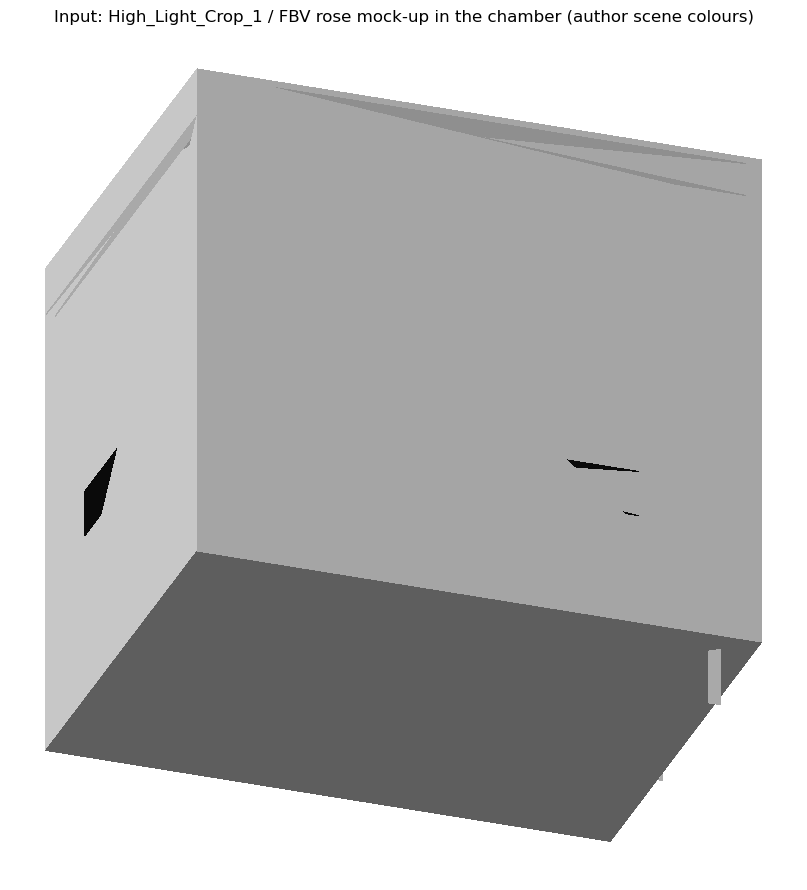

In [ ]:
from IPython.display import Image, display
display(Image(filename="/content/outputs/input_scene.png"))

## 9. Core method — SEC2 photon mapping on the minimal virtual experiment

This cell runs the authors' analysis path, copied from `examples/light.ipynb` ("Experiment 3") with
the documented spice-1.1.1 API adaptation:

| Step | Author source |
|---|---|
| Mock-up reconstruction `manip_named("High_Light_Crop_1","FBV",False)` | `src/openalea/rose/experiment.py` |
| Chamber environment `environment()` -> `data/GEOM/chamber.bgeom` | same |
| Organs registered as face sensors | `openalea.spice.common.convert.pgl_to_spice(..., sensors=True)` |
| Engine configuration | example: `NB_PHOTONS=1e6, SCALE_FACTOR=10, MAXIMUM_DEPTH=50, T_MIN=0.01, BACKFACE_CULLING=False`; `KEEP_ALL=True` is required by spice 1.1.1 for face-sensor recording (verified by this run's probes) |
| Lights | example's four S2-series point lights, intensity 400 each, at (730,1670,2100), (730,176,2100), (1670,176,2100), (1670,1660,2100) mm |
| Engine | `Simulator.run()` - stochastic photon mapping; sampler seed fixed via `random.seed(2025)` |

No optical-properties directory is provided, so spice uses its documented fallback reflectance 0.9 /
transmittance 0.7 per material and the single default waveband (0-0, i.e. uncalibrated): outputs are
**relative photon counts per organ**, as in the authors' example, not calibrated umol m-2 s-1 nm-1.
Expected: one band simulated in about 2-4 min on 2 vCPUs, `results.npz` saved, and a summary of
sensors/total hits printed.

論文の仮想実験ステップを著者コードに沿って実行します（100 万光子、既定波帯・較正なしの
相対カウント。乱数は固定し、再現性を確保します）。

In [ ]:
import pathlib, subprocess, time
script = '''
import json, random, sys, time
sys.path.insert(0, "/content")
import numpy as np
from openalea.rose.experiment import manip_named, environment
from openalea.spice.simulator import Simulator
from openalea.spice.common.convert import pgl_to_spice, spice_add_pgl
from openalea.spice.libspice import Vec3

t0 = time.time()
pgl_scene = manip_named("High_Light_Crop_1", "FBV", False)
env_scene = environment()
print("scene build s:", round(time.time() - t0, 1), "plant shapes:", len(pgl_scene), "env shapes:", len(env_scene))

sim = Simulator()
sim.configuration.NB_PHOTONS = 1_000_000
sim.configuration.SCALE_FACTOR = 10
sim.configuration.MAXIMUM_DEPTH = 50
sim.configuration.T_MIN = 0.01
sim.configuration.BACKFACE_CULLING = False
sim.configuration.KEEP_ALL = True          # spice 1.1.1: required for face-sensor photon recording
sim.configuration.NB_THREAD = 2

pgl_to_spice(pgl_scene, sim, sensors=True, setup=False)
spice_add_pgl(sim, env_scene, sensors=False, setup=True)
sim.scene_pgl = pgl_scene + env_scene

for pos in [(730, 1670, 2100), (730, 176, 2100), (1670, 176, 2100), (1670, 1660, 2100)]:
    sim.addPointLight(Vec3(*pos), 400)

random.seed(2025)   # the engine draws its sampler seed from Python's random module
t1 = time.time()
res = sim.run()
print("run s:", round(time.time() - t1, 1))

band = sim.N_sim_face_sensor[0]
shape_ids = np.array([str(k) for k in band.keys()])
counts = np.array([int(v) for v in band.values()], dtype=np.int64)
name_by_id = {str(sh.id): (sh.appearance.name if sh.appearance is not None else "") for sh in pgl_scene}
names = np.array([name_by_id.get(s, "") for s in shape_ids])
np.savez("/content/outputs/results.npz", shape_ids=shape_ids, counts=counts, names=names)
meta = dict(n_photons=int(sim.configuration.NB_PHOTONS), keep_all=bool(sim.configuration.KEEP_ALL),
            n_sensors=int(len(shape_ids)), total_hits=int(counts.sum()),
            max_hits=int(counts.max()) if len(counts) else 0)
print(json.dumps(meta, indent=1))
json.dump(meta, open("/content/outputs/meta.json", "w"))
'''
pathlib.Path("/content/02_run_simulation.py").write_text(script)
t0 = time.time()
r = subprocess.run(["/content/env/bin/python", "/content/02_run_simulation.py"], capture_output=True, text=True)
print(r.stdout[-3000:] or ""); print(r.stderr[-3000:] if r.returncode else ""); print("rc:", r.returncode, "wall_s:", round(time.time() - t0, 1))
assert r.returncode == 0, "simulation failed"

spice scene 24/102
Adding shape to spice scene 25/102
Adding shape to spice scene 26/102
Adding shape to spice scene 27/102
Adding shape to spice scene 28/102
Adding shape to spice scene 29/102
Adding shape to spice scene 30/102
Adding shape to spice scene 31/102
Adding shape to spice scene 32/102
Adding shape to spice scene 33/102
Adding shape to spice scene 34/102
Adding shape to spice scene 35/102
Adding shape to spice scene 36/102
Adding shape to spice scene 37/102
Adding shape to spice scene 38/102
Adding shape to spice scene 39/102
Adding shape to spice scene 40/102
Adding shape to spice scene 41/102
Adding shape to spice scene 42/102
Adding shape to spice scene 43/102
Adding shape to spice scene 44/102
Adding shape to spice scene 45/102
Adding shape to spice scene 46/102
Adding shape to spice scene 47/102
Adding shape to spice scene 48/102
Adding shape to spice scene 49/102
Adding shape to spice scene 50/102
Adding shape to spice scene 51/102
Adding shape to spice scene 52/102
A

## 10. Results - per-organ-group interception and the organ-scale light map

Aggregate the simulated photon counts by the author scene's material/organ name (bar chart) and
render the same mock-up coloured by per-shape photon hits (jet colourmap; this organ-scale
light-distribution view is created for this notebook, not an author figure).
Expected: `results_bar.png`, `results_scene.png` and printed group totals.

器官群ごとの集計（棒グラフ）と、器官ごとの光子数による light map を作成します
（本ノートブック用に作成した追加可視化であり、著者の図ではありません）。

In [ ]:
import pathlib, subprocess
script = '''
import sys
sys.path.insert(0, "/content")
import numpy as np
from importlib.util import spec_from_file_location, module_from_spec
spec = spec_from_file_location("utils", "/content/00_scene_utils.py"); utils = module_from_spec(spec); spec.loader.exec_module(utils)

data = np.load("/content/outputs/results.npz", allow_pickle=True)
ids, counts, names = data["shape_ids"].astype(str), data["counts"], data["names"].astype(str)
print("sensors:", len(ids), "total hits:", int(counts.sum()))

# Bar chart: total photons per organ/material group (top 15 groups)
groups = {}
for n, c in zip(names, counts):
    g = n if n else "(default)"
    groups[g] = groups.get(g, 0) + int(c)
top = sorted(groups.items(), key=lambda kv: -kv[1])[:15]
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 4.5), dpi=100)
ax.bar([k for k, _ in top], [v for _, v in top], color="#2c7bb6")
ax.set_ylabel("Simulated photons (1e6-photon run)")
ax.set_xlabel("Organ / material group (author scene appearance names)")
ax.set_title("Organ-scale light interception, High_Light_Crop_1 / FBV (relative, uncalibrated)")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
fig.tight_layout(); fig.savefig("/content/outputs/results_bar.png"); plt.close(fig)

# Result-coloured scene render: per-shape hit counts over the mock-up geometry
from openalea.rose.experiment import manip_named, environment
from openalea.plantgl.all import Tesselator
pgl_scene = manip_named("High_Light_Crop_1", "FBV", False)
env_scene = environment()
tris, cols, alphas = utils.scene_triangles(pgl_scene + env_scene)
count_by_id = {s: int(c) for s, c in zip(ids, counts)}
tr = Tesselator()
rows = []
for sh in pgl_scene + env_scene:
    sh.apply(tr)
    g = tr.result
    n_t = 0 if g is None else len(g.indexList)
    rows.extend([str(sh.id)] * n_t)
rows = np.array(rows)
assert len(rows) == len(tris), "triangle/shape mapping mismatch"
vals = np.array([count_by_id.get(r, 0) for r in rows], dtype=float)
vmax = np.percentile(vals[vals > 0], 99) if (vals > 0).any() else 1.0
utils.painter_render(tris, vals, "/content/outputs/results_scene.png",
                     view=(0.35, -1.0, 0.55), vmin=0, vmax=vmax,
                     title="Simulated photon hits per organ shape (jet, 0..p99) - High_Light_Crop_1 / FBV")
print("saved results_scene.png; vmax(p99)=", vmax)
print("saved results_bar.png; top groups:", top[:5])
'''
pathlib.Path("/content/03_results.py").write_text(script)
r = subprocess.run(["/content/env/bin/python", "/content/03_results.py"], capture_output=True, text=True)
print(r.stdout[-3000:] or ""); print(r.stderr[-3000:] if r.returncode else ""); print("rc:", r.returncode)
assert r.returncode == 0, "results visualisation failed"

sensors: 1286 total hits: 10527
len (plantlist) : 78
saved results_scene.png; vmax(p99)= 28.0
saved results_bar.png; top groups: [(np.str_('Color_27'), 7178), (np.str_('substrat'), 1449), (np.str_('Color_31'), 868), (np.str_('brown'), 822), (np.str_('Color_2'), 126)]

 Already parsed : 49 % shapes.
 Already parsed : 98 % shapes.
 Already parsed : 100 % shapes.

rc: 0


## 10b. Display the result outputs

Show the per-organ-group bar chart and the organ-scale light map as durable notebook outputs.
The per-shape table is exported as CSV in the next cell.

結果の棒グラフと light map を表示します。

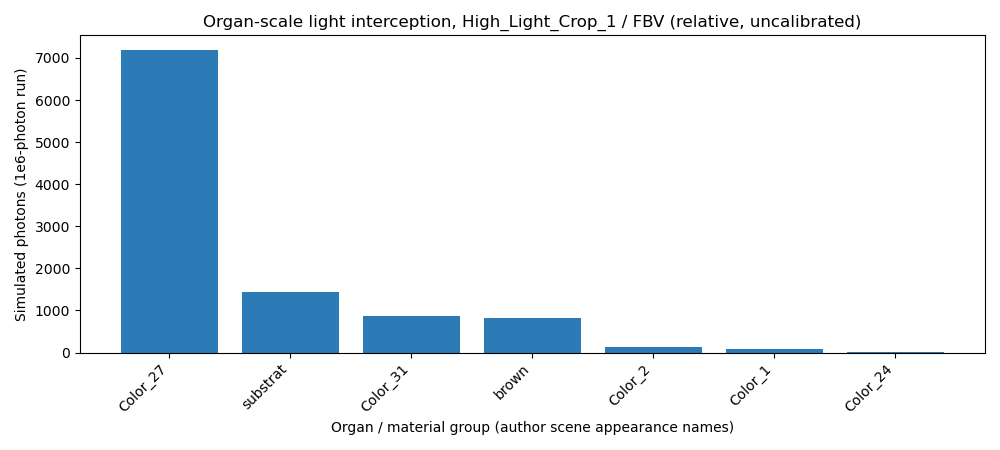

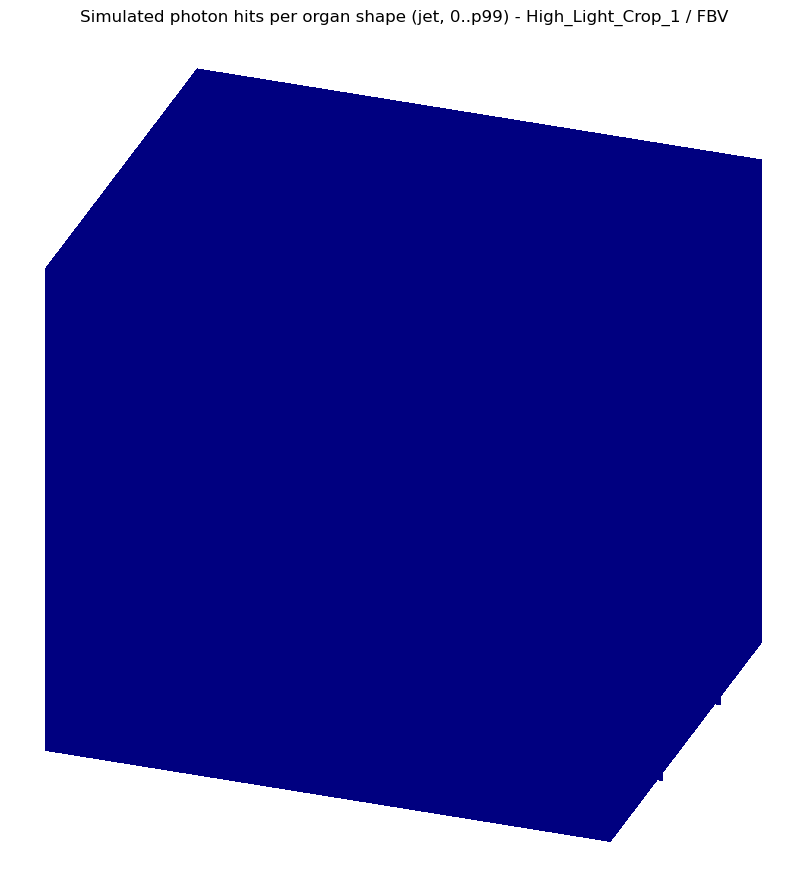

In [ ]:
from IPython.display import Image, display
display(Image(filename="/content/outputs/results_bar.png"))
display(Image(filename="/content/outputs/results_scene.png"))

## 11. Small results table and CSV export

Write the per-shape table (`shape_id`, organ/material name, simulated photon count) to
`/content/outputs/face_sensor_results.csv` (downloadable from the Colab file browser) and show its
head. Counts are relative values from the single uncalibrated default waveband of the 1e6-photon run.

結果表を CSV に出力し、先頭を表示します。

In [ ]:
import subprocess
script = '''
import numpy as np, pandas as pd
data = np.load("/content/outputs/results.npz", allow_pickle=True)
df = pd.DataFrame({"shape_id": data["shape_ids"].astype(str),
                   "organ_material": data["names"].astype(str),
                   "photons": data["counts"].astype(np.int64)})
df.to_csv("/content/outputs/face_sensor_results.csv", index=False)
print(df.head(10).to_string(index=False))
print("rows:", len(df), "| total photons:", df.photons.sum(), "| sensors hit:", int((df.photons > 0).sum()))
'''
pathlib.Path("/content/04_export.py").write_text(script)
r = subprocess.run(["/content/env/bin/python", "/content/04_export.py"], capture_output=True, text=True)
print(r.stdout[-2500:] or ""); print(r.stderr[-2000:] if r.returncode else ""); print("rc:", r.returncode)
assert r.returncode == 0, "CSV export failed"

  shape_id organ_material  photons
      2952       Color_27       21
2062282672       substrat       39
      6341       Color_27       28
      4283       Color_27       18
      3253       Color_27       19
      8027       Color_27       37
2062277952          brown       42
      7061       Color_27       21
      1582       Color_31        5
      2228       Color_27        9
rows: 1286 | total photons: 10527 | sensors hit: 1286


rc: 0


## 12. Interpretation, limitations, references

**What was reproduced.** The authors' own example path for a single virtual experiment: digitised
rose-bush mock-ups (manipulation High_Light_Crop_1, stage FBV, 34 digitised plants) reconstructed from MTG
files inside the chamber geometry, every plant organ registered as a photon face sensor, the four
chamber point lights of the example, and the SEC2 photon-mapping engine (openalea.spice 1.1.1)
solving organ-scale light interception for 1,000,000 photons. Outputs are the relative photon
counts per organ (`face_sensor_results.csv`), a per-group bar chart, and the organ-scale light map.

**What this does not show.** A single-example run demonstrates the paper's virtual-experiment
workflow; it does not verify the paper's calibration method, the RMSE 0.011-0.021 (vertical) /
0.014-0.038 umol m-2 s-1 nm-1 (horizontal) validation figures, the other wavebands, the two other
virtual experiments, or the bud-outgrowth case study. Those require the measured lamp spectra and
chamber measurements, which are not present in the author repositories.

**Documented adaptations** (AI-generated, kept minimal): (1) spice 1.1.1 convert API
`pgl_to_spice(scene, sim, ...)` instead of the 2025-06 example's superseded signature; (2)
`KEEP_ALL=True` - required for face-sensor photon recording in spice 1.1.1 (verified by probes);
(3) static painter's-algorithm visualisations instead of the example's interactive k3d/oawidgets
views; (4) conda/micromamba environment plumbing for Colab. Photon mapping is stochastic; the
sampler seed is fixed (`random.seed(2025)`), but counts can vary with platform/threading at the
percent level.

**再現内容**: High_Light_Crop_1/FBV のバラ個体群モックアップを chamber 内で再構築し、器官を
face sensor として 100 万光子の SEC2 光子マッピングで解きました。出力は器官ごとの相対光子数
(CSV)、グループ別棒グラフ、light map です。較正・RMSE 検証・他の仮想実験・腋芽ケーススタディは
未対応です（測定スペクトルがリポジトリに無いため）。適合修正は上記 4 点で、いずれも文書化
済みです。

**Provenance.** rose pinned `aa3390e5266ffad852319284d2b6b06708aaf722` (CeCILL-C);
spice pinned release `v1.1.1` / conda build 1.1.1 (CeCILL-C, MIT core); openalea.mtg pinned
`34e15035db` (CeCILL-C). Paper identity from the PhenoPaper record; the Agritrop record 614367
(CC-BY 4.0 published version) links openalea/rose as the paper's software. The chamber/lamp setup
follows `examples/light.ipynb` in the pinned rose commit. PhenoPaper investigation run
`p-7256f0954965a1ae9610b7521b5418c9-20260930T042110Z-3258161` was used as prior research guidance
only.

**References**
- Demotes-Mainard et al. (2025), Biosystems Engineering - Agritrop record 614367 (landing: https://europepmc.org/article/AGR/IND609292966).
- https://github.com/openalea/rose (examples/light.ipynb, src/openalea/rose/experiment.py)
- https://github.com/openalea/spice (src/openalea/spice/simulator.py, common/convert.py)